In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [16]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import cogwheel.data
import cogwheel.posterior

sys.path.insert(0, '/home/abbye.williams/GWPE/code')

### create event data

In [4]:
eventname = 'GWexample'
seed = 12
asd_funcs = list(cogwheel.data.ASDS)

# Gaussian noise
event_data = cogwheel.data.EventData.gaussian_noise(
    eventname, duration=128.0, detector_names='HLV', fmax=512.0,
    asd_funcs=asd_funcs, tgps=0.0, seed=seed)

# inject signal
injection_dic = {
    'f_ref' : 100.0,
    'm1' : 60,  # by convention, the heavier object. in Msun
    'm2' : 10,    # in Msun
    's1z' : 0.,
    's2z' : 0.,
    'psi' : 0.5,       # polarization angle
    'iota' : 0.4 * np.pi,      # inclination angle
    's1x_n' : 0.,
    's1y_n' : 0.,
    's2x_n' : 0.,
    's2y_n' : 0.,
    'ra' : 3.,        # in radians
    'dec' : -0.5,       # in radians
    't_geocenter' : 0., # **can I just set this to zero?
    'phi_ref' : 0.43867,    # this is from a random sample from a LVCPrior. is this correct? does this change?
    'd_luminosity' : 500.,  # in Mpc
    'l1' : 0.0,     # **what are these??
    'l2' : 0.0
}
event_data.inject_signal(par_dic=injection_dic, approximant='IMRPhenomXPHM')

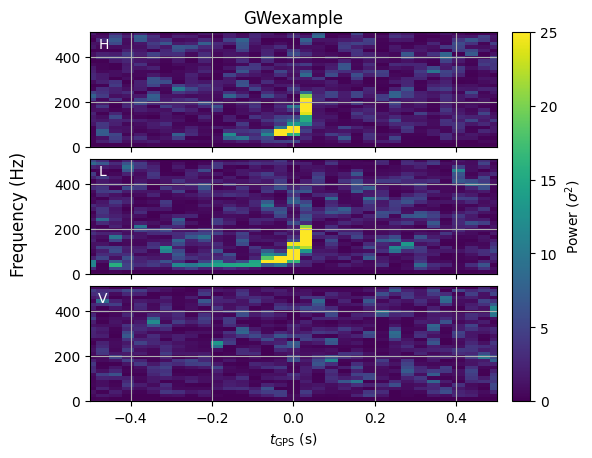

In [14]:
# plot the spectogram
event_data.specgram((-.5, .5))

In [ ]:
# get the Posterior objects (lensed and unlensed) from the event data
prior_class = 'IntrinsicLVCPrior'
injection_dict = event_data.get_init_dict()['injection']
injected_par_dic = injection_dict['par_dic']
mchirp = cogwheel.gw_utils.m1m2_to_mchirp(injected_par_dic['m1'], injected_par_dic['m2'])

# Type II lensed: multiply the strain by i
event_data_lensed = event_data.reinstantiate(strain=1j*event_data.strain)

# instantiate both posteriors: one for the unlensed signal, one for the Type II lensed signal
post = cogwheel.posterior.Posterior.from_event(event_data, mchirp, injection_dict['approximant'], prior_class)
post_lensed = cogwheel.posterior.Posterior.from_event(event_data_lensed, mchirp, injection_dict['approximant'], prior_class)

Setting reference from injection.
Setting reference from injection.


In [30]:
# double check that the par_dic_0 are the same
assert post.likelihood.par_dic_0 == post_lensed.likelihood.par_dic_0

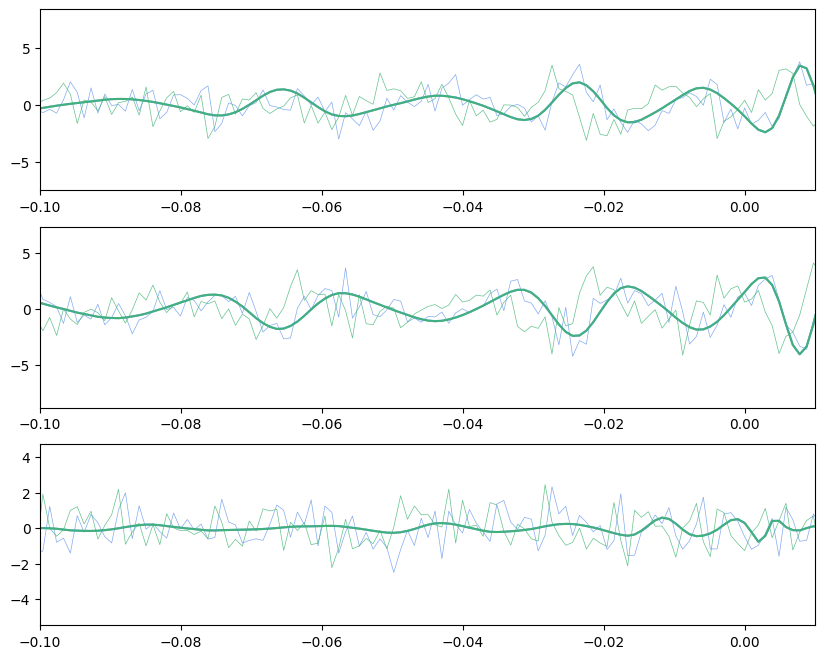

In [34]:
# plot these waveforms
fig, axs = plt.subplots(3, 1, figsize=(10,8))

for p, label, c in zip([post, post_lensed], ['Unlensed', 'Lensed'], ['cornflowerblue', 'mediumseagreen']):
    ed = p.likelihood.event_data
    # apply a small time shift to align the relative binning
    times = ed.times - ed.tcoarse
    # strain
    data_t_wht = ed.get_whitened_td(ed.strain)
    # waveform evaluated at max likelihood params
    wf_t_wht = ed.get_whitened_td(p.likelihood._get_h_f(p.likelihood.par_dic_0))

    for ax, data_det, wf_det in zip(axs, data_t_wht, wf_t_wht):
        ax.plot(times, data_det, c=c, alpha=0.8, lw=0.5)
        ax.plot(times, wf_det, c=c, alpha=0.9, label=label)
        ax.set_xlim(-0.1, 0.01)